# Wall Street's Payroll, in-sample

Rules are fixed in HYPOTHESIS.md. This notebook reads only data/in_sample.parquet.

Change YEAR to flip the trade chart to another year.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import mplfinance as mpf
import numpy as np
import pandas as pd
import strategy as S

YEAR = 2019
VARIANT = "primary"
CAPITAL = 1_000_000

df = pd.read_parquet("data/in_sample.parquet")
print(f"{df.index[0].date()} to {df.index[-1].date()}   {len(df)} trading days")

2010-06-07 to 2024-09-30   3516 trading days


## Where the returns are

Average ES and ZN return by trading day around month-end, before any strategy.

,ES,ZN
T-10,-3.39,0.78
T-9,15.13,1.15
T-8,13.08,-6.01
T-7,1.22,-3.58
T-6,0.96,2.86
T-5,0.05,1.64
T-4,-8.51,-0.84
T-3,11.11,-0.31
T-2,7.76,3.12
T-1,11.07,4.85


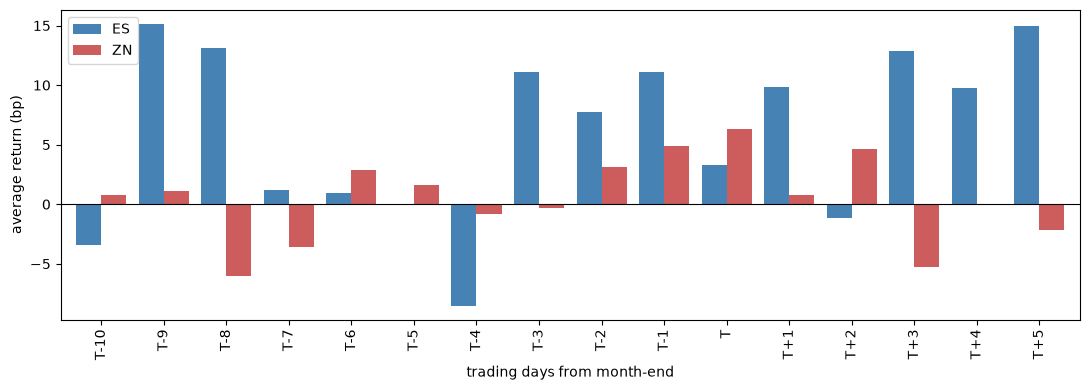

In [2]:
off, ref, me = S.calendar(df.index, -10, 5)
pat = pd.DataFrame({"off": off, "ES": df.es_ret_t.to_numpy(), "ZN": df.zn_ret_t.to_numpy()})
avg = pat.dropna(subset=["off"]).groupby("off")[["ES", "ZN"]].mean() * 1e4
avg.index = [f"T{int(o):+d}".replace("+0", "") for o in avg.index]

fig, ax = plt.subplots(figsize=(11, 4))
avg.plot.bar(ax=ax, width=0.8, color=["steelblue", "indianred"])
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("trading days from month-end")
ax.set_ylabel("average return (bp)")
fig.tight_layout()
fig.savefig("results/month_end_pattern.png", dpi=150)
avg.round(2)

## Costs

Every variant at half, normal and double costs, against buying and holding ES.

In [3]:
tbl = S.table(df)
tbl.round(4).to_csv("results/in_sample_table.csv")
tbl.round(4)

,annual return,volatility,sharpe,max drawdown,turnover
primary 0.5x cost,0.0199,0.0688,0.2887,-0.1429,72.2703
primary 1.0x cost,0.0136,0.0689,0.1977,-0.1547,72.2703
primary 2.0x cost,0.0011,0.0691,0.0162,-0.2068,72.2703
cash 0.5x cost,0.0288,0.0602,0.4779,-0.1090,19.8636
cash 1.0x cost,0.0278,0.0602,0.4614,-0.1099,19.8636
cash 2.0x cost,0.0258,0.0602,0.4283,-0.1117,19.8636
rebal 0.5x cost,0.0133,0.0672,0.1983,-0.2159,72.1186
rebal 1.0x cost,0.0071,0.0674,0.1052,-0.2487,72.1186
rebal 2.0x cost,-0.0054,0.0677,-0.0797,-0.3104,72.1186
both 0.5x cost,0.0428,0.0866,0.4940,-0.1437,78.4176


## Equity curve

Starting from one million dollars.

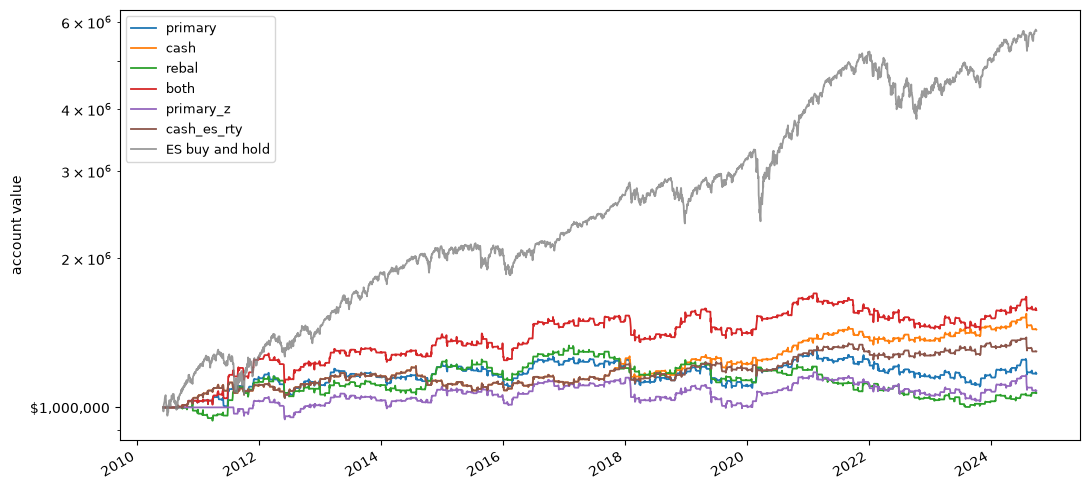

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
for v in S.VARIANTS:
    r, _ = S.run(df, v)
    ((1 + r).cumprod() * CAPITAL).plot(ax=ax, lw=1.3, label=v)
((1 + S.buy_hold(df)).cumprod() * CAPITAL).plot(ax=ax, lw=1.3, color="grey", alpha=0.8, label="ES buy and hold")

ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_ylabel("account value")
ax.set_xlabel("")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("results/equity_in_sample.png", dpi=150)

## What the trades look like

One year of ES candles. Green shading marks the days we hold ES long, with an up marker
where a position opens and a down marker where it closes. ZN sits below with its own
markers. The candles are for display only, the strategy never reads them.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


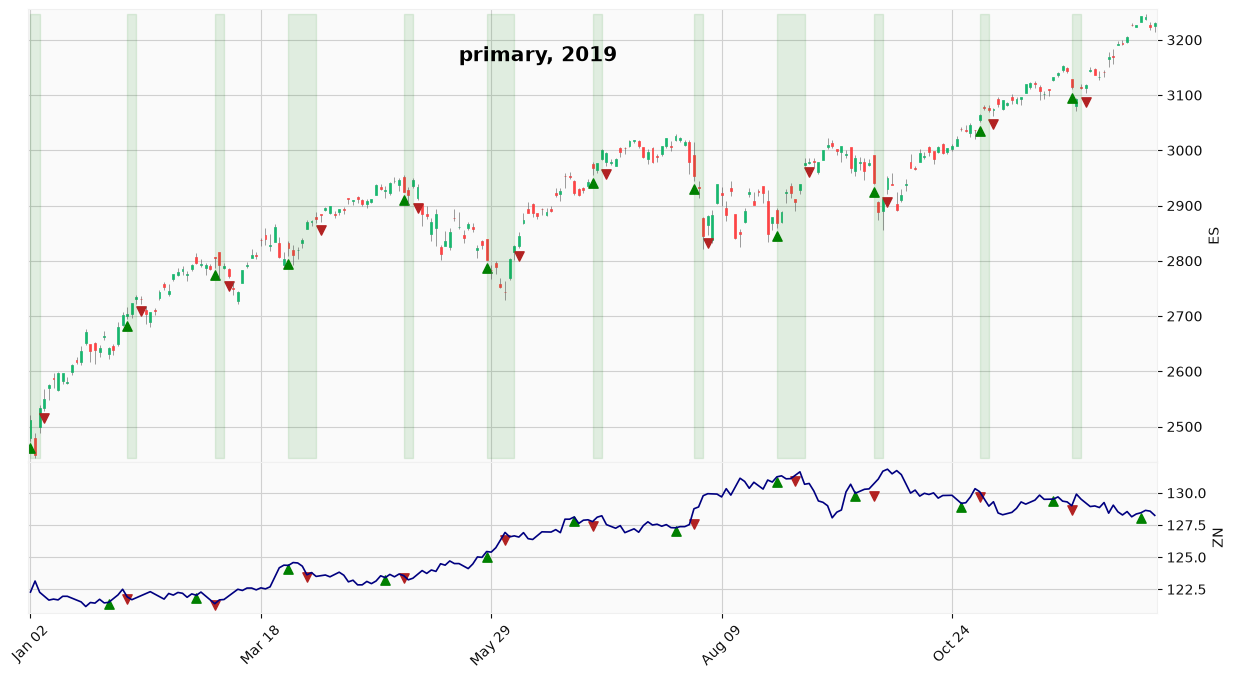

In [5]:
pos = S.positions(df, VARIANT)
yr = df.index.year == YEAR
o = df[yr]
ohlc = pd.DataFrame({"Open": o.es_open, "High": o.es_high, "Low": o.es_low, "Close": o.es_close})

def marks(p, price):
    on = (p != 0).to_numpy()
    return price.where(on & ~np.r_[False, on[:-1]]), price.where(~on & np.r_[False, on[:-1]])

es_in, es_out = marks(pos["es"][yr], o.es_low * 0.995)
zn_in, zn_out = marks(pos["zn"][yr], o.zn_low * 0.999)

ap = []
for s, m, c in ((es_in, "^", "green"), (es_out, "v", "firebrick")):
    if s.notna().any():
        ap.append(mpf.make_addplot(s, type="scatter", marker=m, markersize=45, color=c, panel=0))
ap.append(mpf.make_addplot(o.zn_close, panel=1, color="navy", width=1.2, ylabel="ZN"))
for s, m, c in ((zn_in, "^", "green"), (zn_out, "v", "firebrick")):
    if s.notna().any():
        ap.append(mpf.make_addplot(s, type="scatter", marker=m, markersize=45, color=c, panel=1))

fig, axes = mpf.plot(
    ohlc,
    type="candle",
    style="yahoo",
    addplot=ap,
    fill_between=dict(y1=float(ohlc.Low.min()), y2=float(ohlc.High.max()),
                      where=(pos["es"][yr] > 0).to_numpy(), color="green", alpha=0.10),
    panel_ratios=(3, 1),
    figsize=(13, 7),
    ylabel="ES",
    title=f"{VARIANT}, {YEAR}",
    returnfig=True,
    tight_layout=True,
)
fig.savefig(f"results/trades_{YEAR}.png", dpi=150)

## Every trade

In [6]:
tr = S.trades(df, VARIANT, capital=CAPITAL)
tr.to_csv("results/trades.csv", index=False)

win = tr.pnl > 0
print(f"trades        {len(tr)}")
print(f"win rate      {win.mean():.1%}")
print(f"average win   ${tr.pnl[win].mean():>10,.0f}")
print(f"average loss  ${tr.pnl[~win].mean():>10,.0f}")
print(f"total P&L     ${tr.pnl.sum():>10,.0f}")
tr.head(20)

trades        339
win rate      52.8%
average win   $    10,196
average loss  $   -10,219
total P&L     $   190,064


,instrument,entry,exit,direction,pnl
0,ES,2010-09-02,2010-09-07,long,3337.040686
1,ZN,2010-09-27,2010-10-01,long,335.246981
2,ES,2010-10-01,2010-10-06,long,6400.492954
3,ZN,2010-10-26,2010-11-01,long,9829.857539
4,ES,2010-11-01,2010-11-04,long,11435.699089
5,ZN,2010-11-24,2010-12-01,long,-10996.213869
6,ES,2010-12-01,2010-12-06,long,11682.587550
7,ZN,2010-12-28,2011-01-03,long,-3845.206650
8,ES,2011-01-03,2011-01-06,long,2361.649931
9,ZN,2011-01-26,2011-02-01,long,-2536.627951


## Shifted windows

Both windows moved one day earlier and one day later. The signal day moves with them, so
a shifted run still decides on yesterday's close. This only checks that the result does not
rest on one lucky day. We do not pick windows from it.

In [7]:
shift = {v: {f"{s:+d} day": S.run(df, v, shift=s)[1]["sharpe"] for s in (-1, 0, 1)}
         for v in ("cash", "primary")}
pd.DataFrame(shift).T.round(3)

,-1 day,+0 day,+1 day
cash,0.483,0.461,0.574
primary,0.498,0.198,-0.049


## Random days

A thousand runs that hold ES long on randomly chosen days, the same number of days each
month as the cash variant. If the month-end days matter, the real Sharpe should sit high
in this distribution.

cash     sharpe +0.461   percentile  73.2
primary  sharpe +0.198   percentile  27.2

random days: mean +0.334, 5th -0.041, 95th +0.733


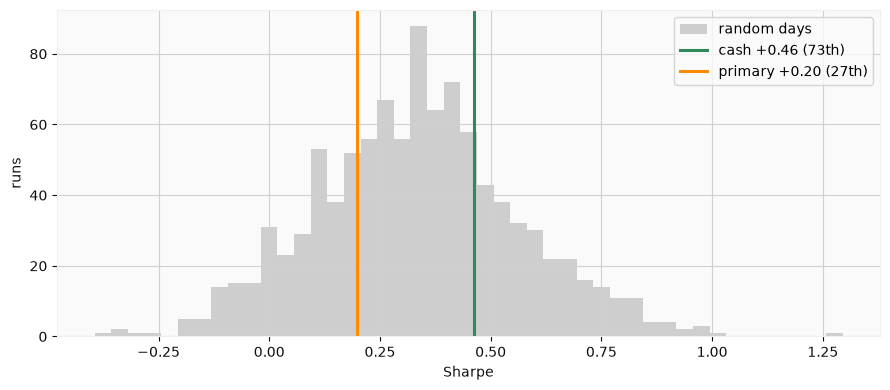

In [8]:
rand = S.random_days(df, n=1000)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(rand, bins=45, alpha=0.75, color="silver", label="random days")
for v, c in (("cash", "seagreen"), ("primary", "darkorange")):
    real = S.run(df, v)[1]["sharpe"]
    pct = (rand < real).mean() * 100
    print(f"{v:<8} sharpe {real:+.3f}   percentile {pct:5.1f}")
    ax.axvline(real, color=c, lw=2.2, label=f"{v} {real:+.2f} ({pct:.0f}th)")

print(f"\nrandom days: mean {rand.mean():+.3f}, 5th {np.percentile(rand,5):+.3f}, 95th {np.percentile(rand,95):+.3f}")
ax.set_xlabel("Sharpe")
ax.set_ylabel("runs")
ax.legend()
fig.tight_layout()
fig.savefig("results/random_windows.png", dpi=150)